# SD 1.5 LoRA Training with Kohya-ss (Kaggle)
**Lab 3 — Architecture SD 1.5**

## Step 1: Configuration

In [1]:
import os
from pathlib import Path

dataset_path = '/kaggle/input/datasets/mirchukliliana/lora-dataset/lora_dataset'
imgs = list(Path(dataset_path).glob('*.jpg')) + list(Path(dataset_path).glob('*.jpeg')) + list(Path(dataset_path).glob('*.png'))

print(f"Dataset path: {dataset_path}")
print(f"Images found: {len(imgs)}")

Dataset path: /kaggle/input/datasets/mirchukliliana/lora-dataset/lora_dataset
Images found: 35


In [ ]:
DATASET_DIR = "/kaggle/input/datasets/mirchukliliana/lora-dataset/lora_dataset" 

OUTPUT_DIR = "/kaggle/working/lora_output_sd15"
OUTPUT_NAME = "my_lora_sd15_v1"

TRIGGER_WORD = "ohwx woman"

# SD 1.5 uses 512x512 resolution
RESOLUTION = 512
TRAIN_BATCH_SIZE = 2      
MAX_TRAIN_STEPS = 1500     
LEARNING_RATE = 1e-4
NETWORK_DIM = 16        
NETWORK_ALPHA = 8
SAVE_EVERY_N_STEPS = 500

## Step 2: Setup Environment

In [4]:
import psutil, shutil, subprocess
ram = psutil.virtual_memory()
print(f"System RAM: {ram.total/1e9:.1f} GB total, {ram.available/1e9:.1f} GB free")

if shutil.which('nvidia-smi'):
    result = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total,memory.free', '--format=csv,noheader'], capture_output=True, text=True)
    print(f"GPU: {result.stdout.strip()}")
else:
    raise RuntimeError("GPU not enabled. Go to Settings -> Accelerator -> GPU T4 x2")

System RAM: 33.7 GB total, 32.2 GB free
GPU: Tesla T4, 15360 MiB, 14913 MiB
Tesla T4, 15360 MiB, 14913 MiB


In [35]:
!pip uninstall -y jax jaxlib flax 2>/dev/null

!git clone https://github.com/kohya-ss/sd-scripts.git /kaggle/working/sd-scripts
%cd /kaggle/working/sd-scripts
!pip install -q -r requirements.txt
!pip install -q xformers


Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
Found existing installation: flax 0.11.2
Uninstalling flax-0.11.2:
  Successfully uninstalled flax-0.11.2
fatal: destination path '/kaggle/working/sd-scripts' already exists and is not an empty directory.
/kaggle/working/sd-scripts
  Preparing metadata (setup.py) ... done

Setup complete.


In [27]:
import os
os.makedirs(os.path.expanduser('~/.cache/huggingface/accelerate'), exist_ok=True)

accelerate_config = """compute_environment: LOCAL_MACHINE
debug: false
distributed_type: 'NO'
downcast_bf16: 'no'
gpu_ids: '0'
machine_rank: 0
main_training_function: main
mixed_precision: fp16
num_machines: 1
num_processes: 1
rdzv_backend: static
same_network: true
tpu_env: []
tpu_use_cluster: false
tpu_use_sudo: false
use_cpu: false
"""

config_path = os.path.expanduser('~/.cache/huggingface/accelerate/default_config.yaml')
with open(config_path, 'w') as f:
    f.write(accelerate_config)
print("Accelerate config written.")

Accelerate config written.


## Step 3: Prepare Dataset Structure

In [28]:
import shutil
from pathlib import Path

src = Path(DATASET_DIR)
images = list(src.glob('*.jpg')) + list(src.glob('*.jpeg')) + list(src.glob('*.png'))
num_images = len(images)
print(f"Found {num_images} images in {DATASET_DIR}")

if num_images == 0:
    images = list(src.rglob('*.jpg')) + list(src.rglob('*.jpeg')) + list(src.rglob('*.png'))
    num_images = len(images)
    print(f"Found {num_images} images recursively")

assert num_images > 0, f"No images found in {DATASET_DIR}! Check the path."

repeats = max(1, round(200 / num_images))
print(f"Using {repeats} repeats per image ({repeats * num_images} images per epoch)")

train_dir = Path('/kaggle/working/train_data_sd15')
subset_dir = train_dir / f'{repeats}_ohwx'
if train_dir.exists():
    shutil.rmtree(train_dir)
subset_dir.mkdir(parents=True, exist_ok=True)

copied = 0
for img in images:
    shutil.copy2(img, subset_dir / img.name)
    txt = img.with_suffix('.txt')
    if txt.exists():
        shutil.copy2(txt, subset_dir / txt.name)
    copied += 1

print(f"Copied {copied} images to {subset_dir}")

Found 35 images in /kaggle/input/datasets/mirchukliliana/lora-dataset/lora_dataset
Using 6 repeats per image (210 images per epoch)
Copied 35 images to /kaggle/working/train_data_sd15/6_ohwx


In [29]:
from pathlib import Path

subset = Path('/kaggle/working/train_data_sd15')
all_imgs = list(subset.rglob('*.jpg')) + list(subset.rglob('*.jpeg')) + list(subset.rglob('*.png'))
all_txts = list(subset.rglob('*.txt'))

print(f"Images: {len(all_imgs)}")
print(f"Captions: {len(all_txts)}")

missing = [img.name for img in all_imgs if not img.with_suffix('.txt').exists()]
if missing:
    print(f"\nWARNING: {len(missing)} images missing captions: {missing[:5]}")

print("\nSample captions:")
for txt in sorted(all_txts)[:3]:
    print(f"  {txt.name}: {txt.read_text()[:120]}...")

Images: 35
Captions: 35

Sample captions:
  01.txt: a photo of ohwx woman with long straight light brown hair, fair skin, green eyes, gentle smile, standing in front of an ...
  02.txt: a photo of ohwx woman with long straight light brown hair, fair skin, green eyes, soft smile, standing in front of a cla...
  03.txt: a photo of ohwx woman with long straight light brown hair, fair skin, green eyes, smiling on a staircase indoors, wearin...


## Step 4: Train LoRA

**SD 1.5 training is much lighter than SDXL:**
- Model is ~3x smaller (~860M vs ~2.6B UNet params)
- 512x512 resolution = 4x fewer pixels to process
- Can use `batch_size=2` easily on T4
- No special memory tricks needed
- Uses `train_network.py` (not `sdxl_train_network.py`)

**Training ~1500 steps takes approximately 15-25 minutes on T4.**

In [30]:
sample_prompts = f"""a photo of {TRIGGER_WORD} with long straight light brown hair, fair skin, green eyes, gentle smile, wearing a cream cardigan, standing in front of a building, bright daylight --n low quality, blurry, deformed --w 512 --h 512 --l 7 --s 28
a photo of {TRIGGER_WORD} with long straight light brown hair, fair skin, green eyes, bright smile, standing by a railing, wearing a brown satin shirt, library background --n low quality, blurry, deformed --w 512 --h 512 --l 7 --s 28
a close-up photo of {TRIGGER_WORD} with long straight light brown hair, fair skin with freckles, green eyes, warm smile, wearing a white eyelet lace blouse, outdoors --n low quality, blurry, deformed --w 512 --h 512 --l 7 --s 28
"""

with open('/kaggle/working/sample_prompts_sd15.txt', 'w') as f:
    f.write(sample_prompts)

print("Sample prompts written.")

Sample prompts written.


In [31]:
import os, gc, torch, time
os.makedirs(OUTPUT_DIR, exist_ok=True)

gc.collect()
torch.cuda.empty_cache()

SD15_MODEL = "stable-diffusion-v1-5/stable-diffusion-v1-5"

start_time = time.time()

!accelerate launch \
    --num_processes=1 \
    --num_machines=1 \
    --mixed_precision=fp16 \
    /kaggle/working/sd-scripts/train_network.py \
    --pretrained_model_name_or_path="{SD15_MODEL}" \
    --train_data_dir="/kaggle/working/train_data_sd15" \
    --output_dir="{OUTPUT_DIR}" \
    --output_name="{OUTPUT_NAME}" \
    --save_model_as=safetensors \
    --resolution={RESOLUTION} \
    --train_batch_size={TRAIN_BATCH_SIZE} \
    --max_train_steps={MAX_TRAIN_STEPS} \
    --learning_rate={LEARNING_RATE} \
    --network_module=networks.lora \
    --network_dim={NETWORK_DIM} \
    --network_alpha={NETWORK_ALPHA} \
    --network_train_unet_only \
    --optimizer_type="AdamW8bit" \
    --lr_scheduler="cosine" \
    --lr_warmup_steps=100 \
    --mixed_precision=fp16 \
    --save_precision=fp16 \
    --gradient_checkpointing \
    --cache_latents \
    --cache_latents_to_disk \
    --xformers \
    --save_every_n_steps={SAVE_EVERY_N_STEPS} \
    --max_data_loader_n_workers=2 \
    --caption_extension=".txt" \
    --seed=42 \
    2>&1 | tee /kaggle/working/train_sd15.log

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed/60:.1f} minutes")

2026-04-15 16:05:30.053897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776269130.276933     207 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776269130.338545     207 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776269130.864410     207 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776269130.864469     207 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776269130.864474     207 computation_placer.cc:177] computation placer alr

In [32]:
!ls -la {OUTPUT_DIR}/

total 53352
drwxr-xr-x 2 root root     4096 Apr 15 16:25 .
drwxr-xr-x 6 root root     4096 Apr 15 16:05 ..
-rw-r--r-- 1 root root 13655664 Apr 15 16:25 my_lora_sd15_v1.safetensors
-rw-r--r-- 1 root root 13655656 Apr 15 16:12 my_lora_sd15_v1-step00000500.safetensors
-rw-r--r-- 1 root root 13655656 Apr 15 16:19 my_lora_sd15_v1-step00001000.safetensors
-rw-r--r-- 1 root root 13655664 Apr 15 16:25 my_lora_sd15_v1-step00001500.safetensors


## Step 5: Generate Images with Your LoRA

In [5]:
import torch, gc
gc.collect()
torch.cuda.empty_cache()

from diffusers import StableDiffusionPipeline, EulerAncestralDiscreteScheduler
from pathlib import Path

lora_files = sorted(Path(OUTPUT_DIR).glob(f"{OUTPUT_NAME}*.safetensors"))
if not lora_files:
    raise FileNotFoundError("No LoRA files found! Make sure training completed.")

print(f"Found LoRA files: {[f.name for f in lora_files]}")
LORA_PATH = str(lora_files[-1])
print(f"Using: {LORA_PATH}")

pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    safety_checker=None,
)
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
pipe.to("cuda")

pipe.load_lora_weights(LORA_PATH)
print("\nPipeline ready with LoRA loaded!")

2026-04-15 16:49:22.857430: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776271762.880162     906 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776271762.887608     906 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776271762.907538     906 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776271762.907561     906 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776271762.907564     906 computation_placer.cc:177] computation placer alr

Found LoRA files: ['my_lora_sd15_v1-step00000500.safetensors', 'my_lora_sd15_v1-step00001000.safetensors', 'my_lora_sd15_v1-step00001500.safetensors', 'my_lora_sd15_v1.safetensors']
Using: /kaggle/working/lora_output_sd15/my_lora_sd15_v1.safetensors


Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .



Pipeline ready with LoRA loaded!


Generating [1/5]: a close-up selfie of ohwx woman with long straight light brown hair, fair skin, ...


  0%|          | 0/28 [00:00<?, ?it/s]

Generating [2/5]: a photo of ohwx woman with long straight light brown hair, fair skin, green eyes...


  0%|          | 0/28 [00:00<?, ?it/s]

Generating [3/5]: a photo of ohwx woman with long straight light brown hair, fair skin, green eyes...


  0%|          | 0/28 [00:00<?, ?it/s]

Generating [4/5]: a close-up selfie of ohwx woman with long straight light brown hair, fair skin, ...


  0%|          | 0/28 [00:00<?, ?it/s]

Generating [5/5]: a photo of ohwx woman with long straight light brown hair, fair skin with freckl...


  0%|          | 0/28 [00:00<?, ?it/s]

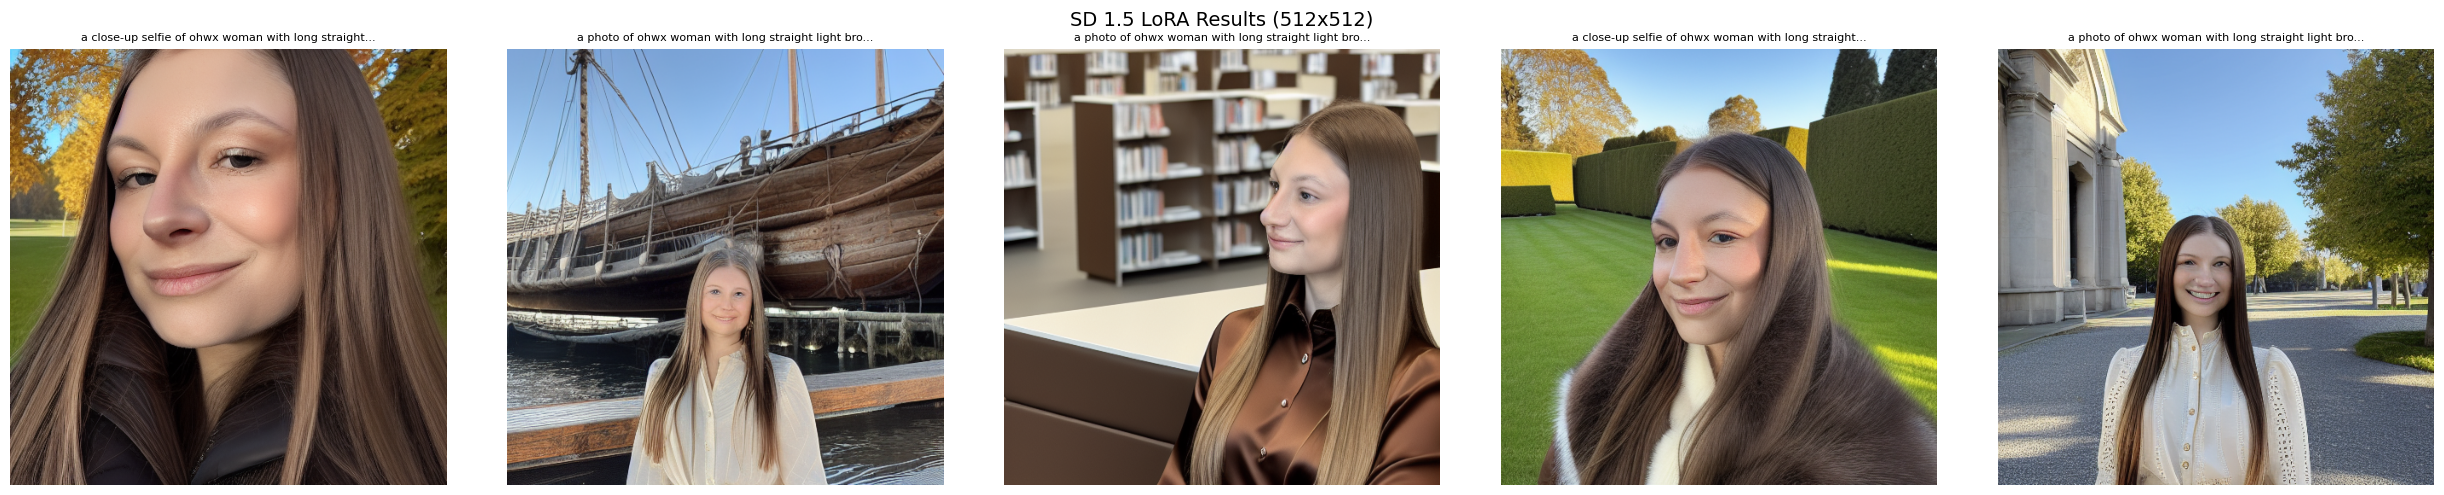


5 images generated and saved to /kaggle/working/lora_output_sd15


In [6]:
import matplotlib.pyplot as plt

test_prompts = [
    f"a close-up selfie of {TRIGGER_WORD} with long straight light brown hair, fair skin, green eyes, warm smile, wearing a black jacket and brown sweater, autumn lakeside",
    f"a photo of {TRIGGER_WORD} with long straight light brown hair, fair skin, green eyes, gentle smile, standing in front of an old wooden ship, wearing a white blouse",
    f"a photo of {TRIGGER_WORD} with long straight light brown hair, fair skin, green eyes, soft smile, sitting in a library, wearing a brown satin shirt, warm indoor lighting",
    f"a close-up selfie of {TRIGGER_WORD} with long straight light brown hair, fair skin, green eyes, warm smile, wearing a white fur coat, overlooking a formal garden",
    f"a photo of {TRIGGER_WORD} with long straight light brown hair, fair skin with freckles, green eyes, cheerful smile, standing in front of a building, wearing a white eyelet lace blouse, natural daylight",
]

negative_prompt = "low quality, blurry, deformed, disfigured, bad anatomy, extra limbs"

images = []
for i, prompt in enumerate(test_prompts):
    print(f"Generating [{i+1}/{len(test_prompts)}]: {prompt[:80]}...")
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=28,
        guidance_scale=7.0,
        width=512,
        height=512,
        generator=torch.Generator("cuda").manual_seed(42),
    ).images[0]
    images.append(image)
    image.save(f"{OUTPUT_DIR}/generated_{i+1}.png")

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for ax, img, prompt in zip(axes, images, test_prompts):
    ax.imshow(img)
    ax.set_title(prompt[:50] + "...", fontsize=8)
    ax.axis('off')
plt.suptitle("SD 1.5 LoRA Results (512x512)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/results_grid_sd15.png", dpi=150)
plt.show()

print(f"\n{len(images)} images generated and saved to {OUTPUT_DIR}")

## Step 6: Compare Checkpoints

Found 4 checkpoints: ['my_lora_sd15_v1-step00000500.safetensors', 'my_lora_sd15_v1-step00001000.safetensors', 'my_lora_sd15_v1-step00001500.safetensors', 'my_lora_sd15_v1.safetensors']

Loading my_lora_sd15_v1-step00000500.safetensors...


  0%|          | 0/28 [00:00<?, ?it/s]


Loading my_lora_sd15_v1-step00001000.safetensors...


  0%|          | 0/28 [00:00<?, ?it/s]


Loading my_lora_sd15_v1-step00001500.safetensors...


  0%|          | 0/28 [00:00<?, ?it/s]


Loading my_lora_sd15_v1.safetensors...


  0%|          | 0/28 [00:00<?, ?it/s]

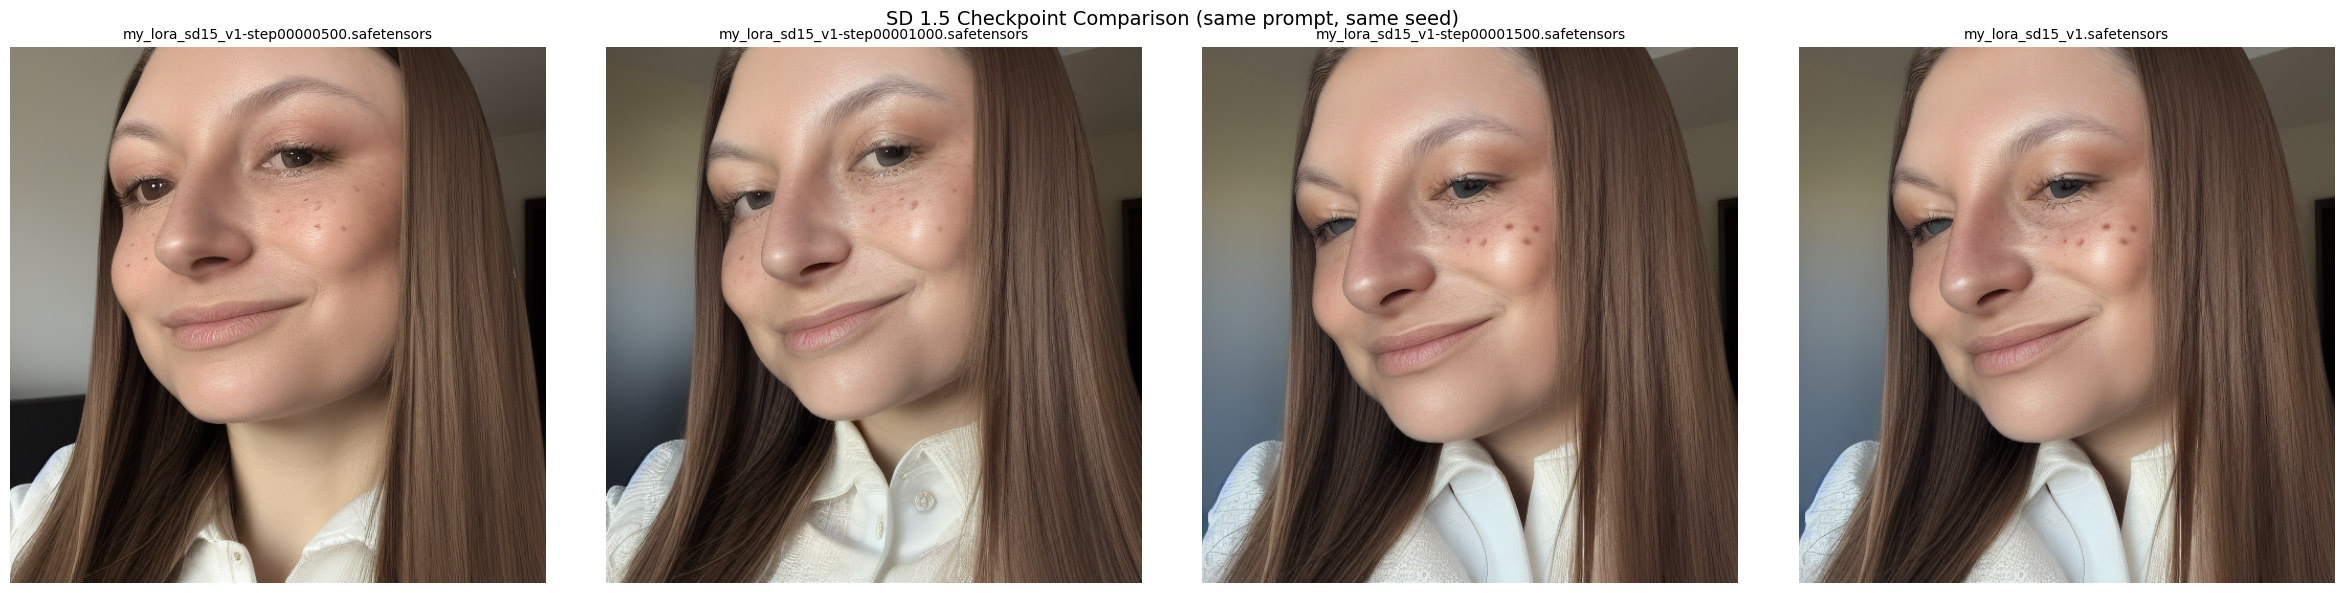

In [7]:
from pathlib import Path
import matplotlib.pyplot as plt

checkpoints = sorted(Path(OUTPUT_DIR).glob(f"{OUTPUT_NAME}*.safetensors"))
print(f"Found {len(checkpoints)} checkpoints: {[c.name for c in checkpoints]}")

test_prompt = f"a close-up photo of {TRIGGER_WORD} with long straight light brown hair, fair skin with freckles, green eyes, gentle warm smile, wearing a white blouse, natural daylight"
negative_prompt = "low quality, blurry, deformed"

comparison_images = []
for ckpt in checkpoints:
    print(f"\nLoading {ckpt.name}...")
    pipe.unload_lora_weights()
    pipe.load_lora_weights(str(ckpt))

    img = pipe(
        prompt=test_prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=28,
        guidance_scale=7.0,
        width=512, height=512,
        generator=torch.Generator("cuda").manual_seed(42),
    ).images[0]
    comparison_images.append((ckpt.name, img))

n = len(comparison_images)
fig, axes = plt.subplots(1, n, figsize=(6*n, 6))
if n == 1:
    axes = [axes]
for ax, (name, img) in zip(axes, comparison_images):
    ax.imshow(img)
    ax.set_title(name, fontsize=10)
    ax.axis('off')
plt.suptitle("SD 1.5 Checkpoint Comparison (same prompt, same seed)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/checkpoint_comparison_sd15.png", dpi=150)
plt.show()

## Step 7: Download Results

In [8]:
import os
print("Output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_mb = os.path.getsize(f"{OUTPUT_DIR}/{f}") / 1e6
    print(f"  {f} ({size_mb:.1f} MB)")

print(f"\nTotal files: {len(os.listdir(OUTPUT_DIR))}")
print("Available in the Output tab after notebook execution.")

Output files:
  checkpoint_comparison_sd15.png (2.6 MB)
  generated_1.png (0.5 MB)
  generated_2.png (0.5 MB)
  generated_3.png (0.4 MB)
  generated_4.png (0.5 MB)
  generated_5.png (0.5 MB)
  my_lora_sd15_v1-step00000500.safetensors (13.7 MB)
  my_lora_sd15_v1-step00001000.safetensors (13.7 MB)
  my_lora_sd15_v1-step00001500.safetensors (13.7 MB)
  my_lora_sd15_v1.safetensors (13.7 MB)
  results_grid_sd15.png (3.7 MB)

Total files: 11
Available in the Output tab after notebook execution.
